# GraphRAG Question Answering

This notebook explores a graph-based Retrieval-Augmented Generation (GraphRAG) approach for question answering over *12 Angry Men*.

Instead of retrieving independent document chunks, the system operates over a pre-built knowledge graph representing entities and relationships from the screenplay.

For each question, the pipeline identifies relevant graph elements, explores their local neighborhoods, and converts the retrieved subgraph into structured evidence for an instruction-tuned language model.

The experiments investigate how graph traversal depth, retrieved evidence, community-level information, and graph quality affect question-answering performance.

> **Implementation note:** The knowledge graph used in this notebook was provided as part of the course assignment. The project work focuses on graph inspection and correction, retrieval, traversal, evidence construction, experimentation, and evaluation.

## Knowledge Graph Inspection and Correction

The provided knowledge graph is inspected before retrieval to identify structural or semantic inconsistencies that could affect downstream question answering. Targeted corrections are applied where necessary so that retrieval and traversal operate over a more coherent graph representation.

This notebook works with a pre-built knowledge graph provided as the starting point for the project. The work focuses on graph inspection, cleanup, retrieval, traversal, evidence construction, and evaluation rather than graph construction from scratch.

## GraphRAG Question Answering Pipeline

For each question, the system performs the following steps:

1. Identify relevant graph nodes and edges.
2. Expand around those matches with multi-hop graph traversal.
3. Convert the retrieved subgraph into textual evidence.
4. Optionally incorporate community summaries as additional context.
5. Pass the evidence to the language model for answer generation.

The pipeline is designed to ground question answering in the screenplay graph rather than relying on unstructured recall alone.

## Graph Setup and Data Loading

In [ ]:
from pathlib import Path
import json
import re

import networkx as nx
import pandas as pd
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Input files
GRAPH_JSON_PATH = Path("graph.json")
COMMUNITY_SUMMARIES_PATH = Path("community_summaries.json")
QUESTIONS_CSV_PATH = Path("questions.csv")

# Output file
OUTPUT_CSV_PATH = Path("generated_answers.csv")

## Graph Loading

In [ ]:
def load_graph_json(path: Path) -> nx.DiGraph:
    # Load graph_clean.json into a NetworkX DiGraph.
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    G = nx.DiGraph()

    for node in data["nodes"]:
        node_id = str(node["id"])
        props = dict(node.get("properties", {}))
        props.pop("name", None)
        props.pop("entity_type", None)
        G.add_node(
            node_id,
            name=str(node.get("name") or node_id),
            entity_type=str(node.get("entity_type") or "entity"),
            **props,
        )

    for i, edge in enumerate(data["edges"]):
        source = str(edge["source"])
        target = str(edge["target"])
        props = dict(edge.get("properties", {}))
        relation = str(edge.get("relation") or props.get("relation") or "RELATED_TO")
        description = str(edge.get("description") or props.get("description") or props.get("relationship_description") or "")
        props.pop("relation", None)
        props.pop("description", None)
        props.pop("relationship_description", None)
        G.add_edge(
            source,
            target,
            relation=relation,
            description=description,
            edge_id=str(props.get("rel_id") or i),
            **props,
        )

    return G

G = load_graph_json(GRAPH_JSON_PATH)
print("Graph loaded")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph loaded
Nodes: 77
Edges: 220


## Knowledge Graph Inspection

In [ ]:
def graph_overview(G: nx.DiGraph, top_n: int = 15):
    rows = []
    for node_id, degree in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:top_n]:
        rows.append({
            "node_id": node_id,
            "name": G.nodes[node_id].get("name", node_id),
            "entity_type": G.nodes[node_id].get("entity_type", ""),
            "degree": degree,
        })
    return pd.DataFrame(rows)

graph_overview(G)

,node_id,name,entity_type,degree
0,JUROR #8,JUROR #8,entity,39
1,FOREMAN,FOREMAN,entity,37
2,JUROR #4,JUROR #4,entity,27
3,JUROR #3,JUROR #3,entity,26
4,JUROR #10,JUROR #10,CHARACTER,21
5,JUROR #7,JUROR #7,entity,18
6,JUROR #11,JUROR #11,entity,16
7,JUROR #9,JUROR #9,CHARACTER,15
8,#3,#3,entity,15
9,#8,#8,entity,15


### Edge Frequency Analysis

In [ ]:
relation_counts = pd.Series([data.get("relation", "") for _, _, data in G.edges(data=True)]).value_counts()
relation_counts.head(20).to_frame("count")

,count
QUESTIONS,17
SUPPORTS,10
ARGUES_WITH,10
ADDRESSES,9
CHALLENGES,7
CALMS,6
CONTRADICTS,6
RESPONDS_TO,5
DISCUSSES,4
AGREES_WITH,4


### Knowledge Graph Inspection and Correction

Original Graph Size --> Nodes: 77 | Edges: 220
Nodes: 77
Edges: 220
FOREMAN --> {'name': 'FOREMAN', 'entity_type': 'entity', 'source': '12 Angry Men screenplay', 'url': 'https://f004.backblazeb2.com/file/screenplays/posts/12-angry-men-1957/scripts/12%20Angry%20Men%20-%20Release.pdf', 'chunk_id': '55', 'chunk_type': 'screenplay_structural_chunk', 'scene_heading': 'EXT. LONG SHOT - N. Y. - COURT OF GENERAL SESSIONS - DAY', 'start_page': '132', 'end_page': '135', 'relationship_description': 'Juror #4 presses Juror #12 for his opinion on the case and his willingness to vote for acquittal.', 'triplet_source_id': 'd83de627-27fe-4e09-8166-6a7c5ae465fa'}
JUROR #2 --> {'name': 'JUROR #2', 'entity_type': 'entity', 'source': '12 Angry Men screenplay', 'url': 'https://f004.backblazeb2.com/file/screenplays/posts/12-angry-men-1957/scripts/12%20Angry%20Men%20-%20Release.pdf', 'chunk_id': '59', 'chunk_type': 'screenplay_structural_subchunk', 'scene_heading': 'EXT. LONG SHOT - N. Y. - COURT OF GENERAL 

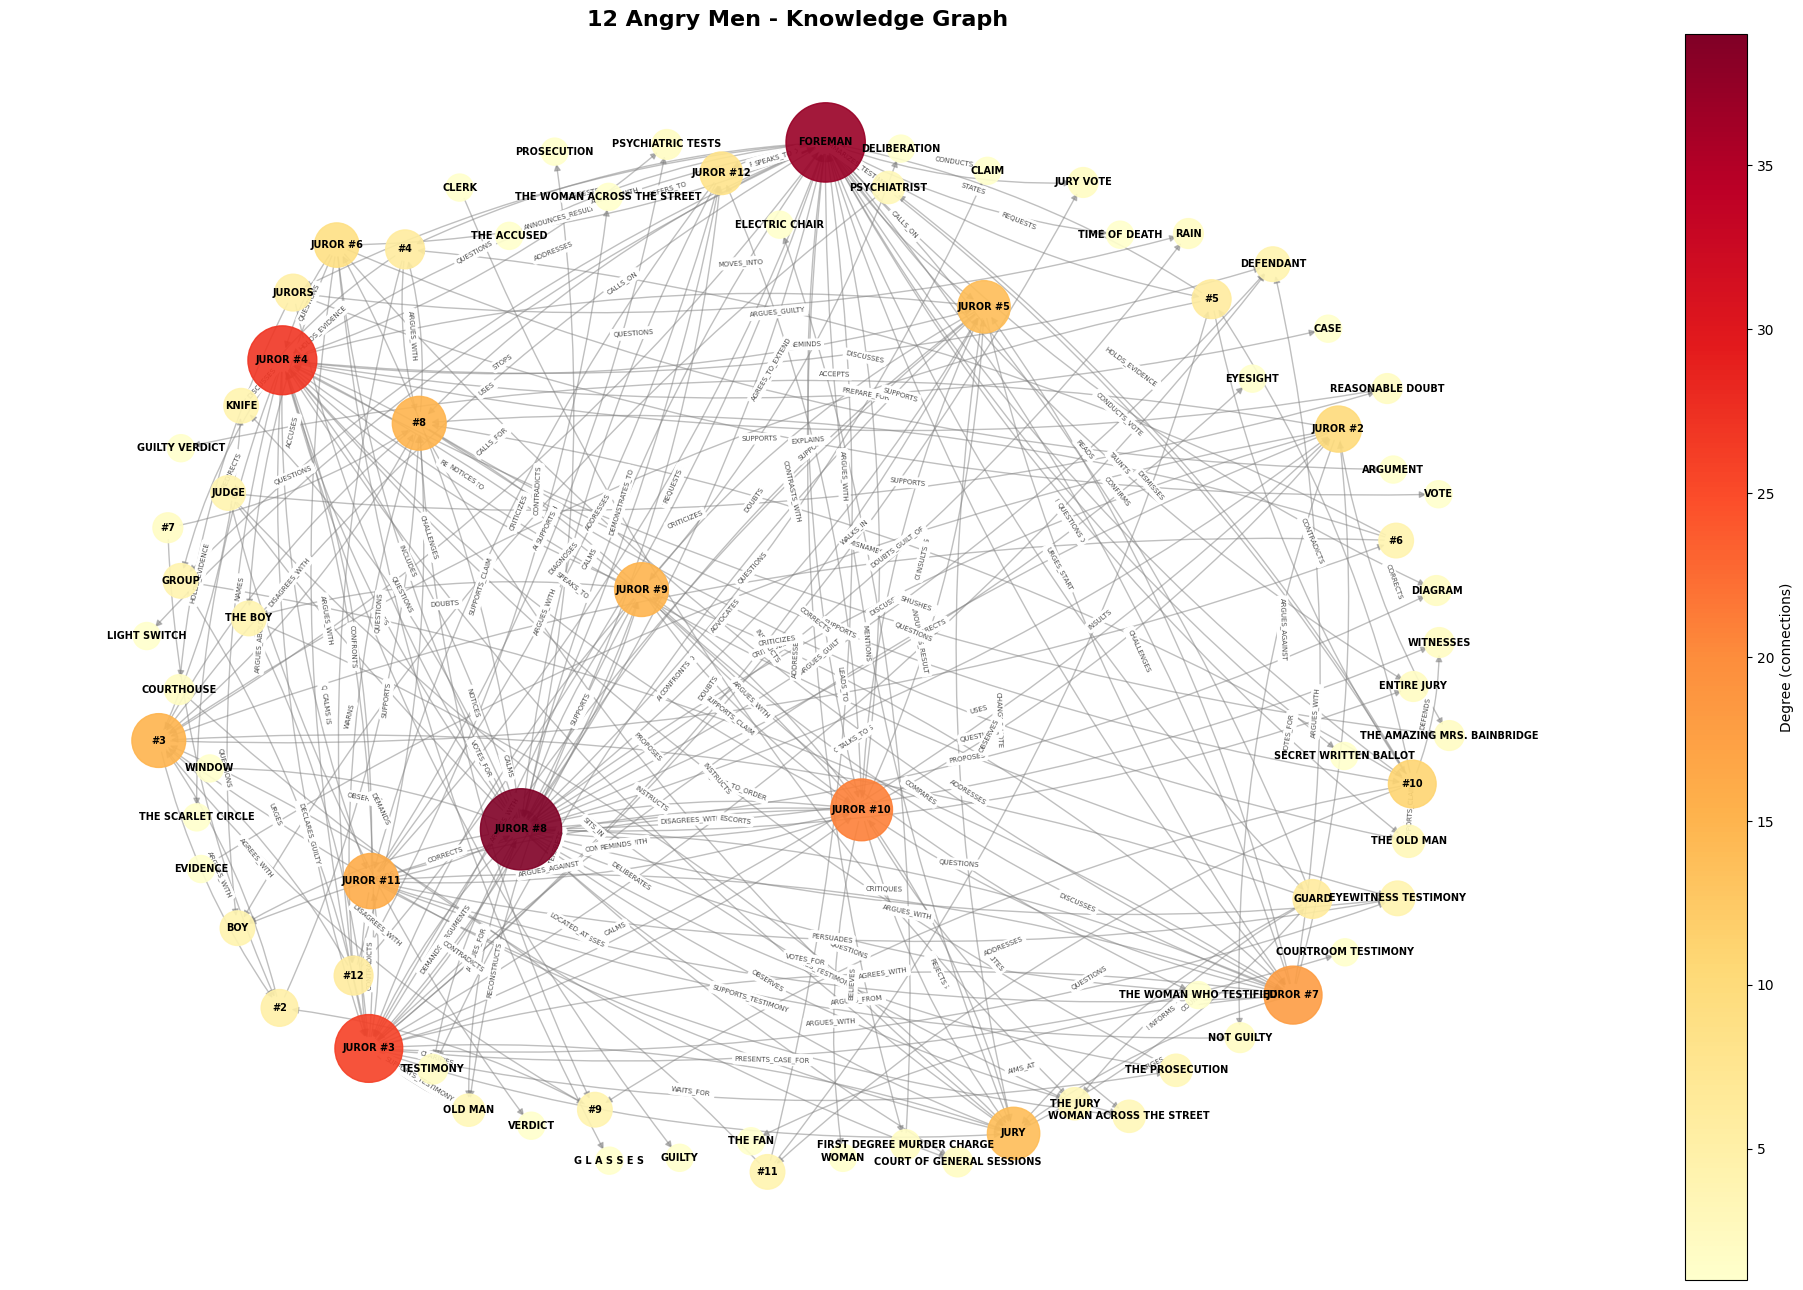

Saved as graph_visualization.png


In [ ]:
# =========================================================
# Graph Inspection and Correction
# =========================================================
# The graph 'G' is already loaded in memory.

# --- 1. INSPECTION ---
# Graph visualization and structural inspection.

import matplotlib.pyplot as plt
import networkx as nx

print("Original Graph Size --> Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())

# Basic statistics
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# A few node examples to inspect their structure
for node_id, data in list(G.nodes(data=True))[:5]:
    print(node_id, "-->", data)

plt.figure(figsize=(20, 13))

# Layout - spring places highly connected nodes near the center
pos = nx.spring_layout(G, seed=42, k=2.5)

# Colors based on degree
degrees = dict(G.degree())
node_colors = [degrees[n] for n in G.nodes()]

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    node_size=[300 + degrees[n] * 80 for n in G.nodes()],
    alpha=0.9
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=7,
    font_weight='bold'
)

# Edges
nx.draw_networkx_edges(
    G, pos,
    edge_color='gray',
    arrows=True,
    arrowsize=10,
    alpha=0.5,
    connectionstyle='arc3,rad=0.1'
)

# Edge labels (relation)
edge_labels = {(u, v): data.get('relation', '') for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=5,
    alpha=0.7
)

plt.title("12 Angry Men - Knowledge Graph", fontsize=16, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=plt.gca(), label="Degree (connections)")
plt.axis('off')
plt.tight_layout()
plt.savefig("graph_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved as graph_visualization.png")

In [ ]:
# Identify duplicates or inconsistent graph entries.
# Inspect the graph for likely duplicates or structural inconsistencies.
# Check for duplicate names that map to different node IDs.

# All node names
all_names = [(node_id, data.get("name", "")) for node_id, data in G.nodes(data=True)]
for node_id, name in sorted(all_names, key=lambda x: x[1]):
    print(f"ID: {node_id!r:30s} | name: {name!r}")

suspects = [
    'JURY', 'JURORS', 'ENTIRE JURY',
    'GUILTY', 'GUILTY VERDICT',
    'EYEWITNESS TESTIMONY', 'COURTROOM TESTIMONY',
    'COURT OF GENERAL SESSIONS', 'COURTHOUSE',
]

for node in suspects:
    if node in G:
        neighbors = list(G.predecessors(node)) + list(G.successors(node))
        print(f"\n[{node}] | degree: {G.degree(node)}")
        for u, v, data in list(G.in_edges(node, data=True)) + list(G.out_edges(node, data=True)):
            print(f"  {u} --({data.get('relation','?')})-> {v}")




ID: '#10'                          | name: '#10'
ID: '#11'                          | name: '#11'
ID: '#12'                          | name: '#12'
ID: '#2'                           | name: '#2'
ID: '#3'                           | name: '#3'
ID: '#4'                           | name: '#4'
ID: '#5'                           | name: '#5'
ID: '#6'                           | name: '#6'
ID: '#7'                           | name: '#7'
ID: '#8'                           | name: '#8'
ID: '#9'                           | name: '#9'
ID: 'ARGUMENT'                     | name: 'ARGUMENT'
ID: 'BOY'                          | name: 'BOY'
ID: 'CASE'                         | name: 'CASE'
ID: 'CLAIM'                        | name: 'CLAIM'
ID: 'CLERK'                        | name: 'CLERK'
ID: 'COURT OF GENERAL SESSIONS'    | name: 'COURT OF GENERAL SESSIONS'
ID: 'COURTHOUSE'                   | name: 'COURTHOUSE'
ID: 'COURTROOM TESTIMONY'          | name: 'COURTROOM TESTIMONY'
ID: 'DEFENDANT'       

In [ ]:
# Apply targeted graph cleanup where required.
# Apply targeted graph corrections when structural issues are found.
# Helpful NetworkX functions:
# - G.remove_node(node_id)
# - G.remove_edge(u, v)
# - nx.contracted_nodes(G, node_to_keep, node_to_merge) # Great for merging duplicates!
print("\nInitial Graph Size --> Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())

duplicates = [
    ('#2',  'JUROR #2'),
    ('#3',  'JUROR #3'),
    ('#4',  'JUROR #4'),
    ('#5',  'JUROR #5'),
    ('#6',  'JUROR #6'),
    ('#7',  'JUROR #7'),
    ('#8',  'JUROR #8'),
    ('#9',  'JUROR #9'),
    ('#10', 'JUROR #10'),
    ('#11', 'JUROR #11'),
    ('#12', 'JUROR #12'),
]

# Apply targeted graph cleanup where required.

# Jury duplicates
for node_to_remove in ['JURORS', 'ENTIRE JURY']:
    if node_to_remove in G and 'JURY' in G:
        G = nx.contracted_nodes(G, 'JURY', node_to_remove, self_loops=False)
        print(f"Merged '{node_to_remove}' --> 'JURY'")

# Guilty duplicates
if 'GUILTY' in G and 'GUILTY VERDICT' in G:
    G = nx.contracted_nodes(G, 'GUILTY VERDICT', 'GUILTY', self_loops=False)
    print("Merged 'GUILTY' --> 'GUILTY VERDICT'")

# Testimony duplicates
if 'COURTROOM TESTIMONY' in G and 'EYEWITNESS TESTIMONY' in G:
    G = nx.contracted_nodes(G, 'EYEWITNESS TESTIMONY', 'COURTROOM TESTIMONY', self_loops=False)
    print("Merged 'COURTROOM TESTIMONY' --> 'EYEWITNESS TESTIMONY'")

for node_to_remove, node_to_keep in duplicates:
    if node_to_remove in G and node_to_keep in G:
        G = nx.contracted_nodes(G, node_to_keep, node_to_remove, self_loops=False)
        print(f"Merged '{node_to_remove}' --> '{node_to_keep}'")


# --- VERIFICATION ---
print("Cleaned Graph Size  --> Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())


Initial Graph Size --> Nodes: 77 | Edges: 220
Merged 'JURORS' --> 'JURY'
Merged 'ENTIRE JURY' --> 'JURY'
Merged 'GUILTY' --> 'GUILTY VERDICT'
Merged 'COURTROOM TESTIMONY' --> 'EYEWITNESS TESTIMONY'
Merged '#2' --> 'JUROR #2'
Merged '#3' --> 'JUROR #3'
Merged '#4' --> 'JUROR #4'
Merged '#5' --> 'JUROR #5'
Merged '#6' --> 'JUROR #6'
Merged '#7' --> 'JUROR #7'
Merged '#8' --> 'JUROR #8'
Merged '#9' --> 'JUROR #9'
Merged '#10' --> 'JUROR #10'
Merged '#11' --> 'JUROR #11'
Merged '#12' --> 'JUROR #12'
Cleaned Graph Size  --> Nodes: 62 | Edges: 182


## Graph-to-Text Evidence Conversion

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Converting Graph Structure into Searchable Text

In [ ]:
import re
import networkx as nx


def clean_text(x) -> str:
    if x is None:
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()


def node_to_text(G: nx.DiGraph, node_id: str) -> str:
    data = G.nodes[node_id]

    name = data.get("name", node_id)
    entity_type = data.get("entity_type", "")
    entity_description = data.get("entity_description", "")
    relationship_description = data.get("relationship_description", "")
    scene_heading = data.get("scene_heading", "")
    start_page = data.get("start_page", "")
    end_page = data.get("end_page", "")

    text = (
        f"Node name: {name}. "
        f"Entity type: {entity_type}. "
        f"Entity description: {entity_description}. "
        f"Related description: {relationship_description}. "
        f"Scene heading: {scene_heading}. "
        f"Pages: {start_page}-{end_page}."
    )

    return clean_text(text)


def edge_to_text(G: nx.DiGraph, source: str, target: str, data: dict) -> str:
    source_name = G.nodes[source].get("name", source)
    target_name = G.nodes[target].get("name", target)

    relation = data.get("relation", "")
    description = data.get("description", "") or data.get("relationship_description", "")

    start_page = data.get("start_page", "")
    end_page = data.get("end_page", "")

    text = (
        f"Source: {source_name}. "
        f"Target: {target_name}. "
        f"Relation: {relation}. "
        f"Description: {description}. "
        f"Pages: {start_page}-{end_page}."
    )

    return clean_text(text)


node_ids = list(G.nodes())
node_texts = [node_to_text(G, node_id) for node_id in node_ids]

edge_records = []
edge_texts = []

for source, target, data in G.edges(data=True):
    text = edge_to_text(G, source, target, data)
    edge_records.append((source, target, data, text))
    edge_texts.append(text)

print("Node documents:", len(node_texts))
print("Edge documents:", len(edge_texts))

if edge_texts:
    print("Example edge text:\n", edge_texts[0])

Node documents: 62
Edge documents: 182
Example edge text:
 Source: FOREMAN. Target: JURY. Relation: ANNOUNCES_RESULT. Description: The foreman states that the vote is nine to three in favor of acquittal.. Pages: 126-128.


## Text Embedding and Retrieval Features

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# TF-IDF indexes
node_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
)

node_tfidf_matrix = node_vectorizer.fit_transform(node_texts)


edge_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
)

edge_tfidf_matrix = edge_vectorizer.fit_transform(edge_texts)


# Semantic embedding indexes
node_embedding_matrix = embedding_model.encode(
    node_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

edge_embedding_matrix = embedding_model.encode(
    edge_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)


print("Node TF-IDF matrix:", node_tfidf_matrix.shape)
print("Edge TF-IDF matrix:", edge_tfidf_matrix.shape)
print("Node embedding matrix:", node_embedding_matrix.shape)
print("Edge embedding matrix:", edge_embedding_matrix.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Node TF-IDF matrix: (62, 797)
Edge TF-IDF matrix: (182, 2296)
Node embedding matrix: (62, 384)
Edge embedding matrix: (182, 384)


### Community Summary Context

In [ ]:
import json

with open("community_summaries.json", "r", encoding="utf-8") as f:
    community_summaries = json.load(f)

In [ ]:
community_ids = []
community_texts = []
# Change to true to use community summaries
use_community_summaries = True

if use_community_summaries:
    community_ids = list(community_summaries.keys())
    community_texts = [community_summaries[cid] for cid in community_ids]

    community_vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
    )

    community_tfidf_matrix = community_vectorizer.fit_transform(community_texts)

    community_embedding_matrix = embedding_model.encode(
        community_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    print("Community summaries:", len(community_texts))
    print("Community TF-IDF matrix:", community_tfidf_matrix.shape)
    print("Community embedding matrix:", community_embedding_matrix.shape)

else:
    community_vectorizer = None
    community_tfidf_matrix = None
    community_embedding_matrix = None

    print("No community summaries loaded.")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Community summaries: 23
Community TF-IDF matrix: (23, 728)
Community embedding matrix: (23, 384)


## Graph Retrieval Components

In [ ]:
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================================================
# Hyperparameters for graph retrieval and evidence selection
# =========================================================
TOP_K_SEED_NODES = 5
TOP_K_SEED_EDGES = 8
TOP_K_EVIDENCE_LINES = 12
TOP_K_COMMUNITIES = 3
HOPS = 1

USE_COMMUNITY_SUMMARIES = True
KEYWORD_WEIGHT = 0.70
EMBEDDING_WEIGHT = 0.30

# =========================================================
# 1. QUERY EXPANSION & UTILITIES
# =========================================================
QUERY_EXPANSIONS = {
    "weather": "heat hot hottest rain rainy raining storm",
    "witness": "eyewitness testimony saw heard",
    "knife": "switchblade weapon blade",
    "boy": "defendant accused the accused",
    "old man": "witness elderly man",
    "woman": "woman across the street eyewitness",
    "glasses": "eye glasses eyesight vision",
    "vote": "ballot verdict guilty not guilty",
    "reasonable doubt": "doubt uncertainty evidence",
    "juror": "jury jurors foreman",
    "murder": "first degree murder charge crime",
    "testimony": "witness eyewitness courtroom testimony",
    "guard": "evidence knife diagram holds_evidence exhibit",
    "evidence": "knife diagram exhibit guard holds_evidence",
}

def expand_query(query: str) -> str:
    """
    Expands a user query by appending synonyms.
    Inputs: query (str) | Outputs: expanded_query (str)
    """
    expanded_query = query
# Expand query terms by appending known synonyms when present.
    query_lower = query.lower()

    for key, expansion in QUERY_EXPANSIONS.items():
        if key.lower() in query_lower:
            expanded_query += " " + expansion

    return expanded_query

def normalize_scores(scores):
    """Min-Max normalization. Brings array values between 0.0 and 1.0. (Provided)"""
    scores = np.asarray(scores, dtype=float)
    if len(scores) == 0: return scores
    min_score, max_score = scores.min(), scores.max()
    if max_score == min_score: return np.zeros_like(scores)
    return (scores - min_score) / (max_score - min_score)

def subgraph_to_evidence_lines(subgraph: nx.DiGraph):
    """Converts a NetworkX subgraph into readable text lines. (Provided)"""
    lines = []
    for source, target, data in subgraph.edges(data=True):
        lines.append(edge_to_text(subgraph, source, target, data))
    return lines

# =========================================================
# Core Hybrid Search Algorithm
# =========================================================
def hybrid_search(query: str, texts, ids, tfidf_vectorizer, tfidf_matrix, embedding_matrix, top_k: int, keyword_weight: float = KEYWORD_WEIGHT, embedding_weight: float = EMBEDDING_WEIGHT):
    """
    Executes a hybrid search using both TF-IDF (keywords) and Embeddings (semantics).
    Outputs: results (list of dicts) containing id, score, text, etc.
    """
    results = []

# Retrieve the most relevant community summaries.
    # 1. Expand the query.
    expanded_query = expand_query(query)

    # 2. Calculate keyword_scores (using tfidf_matrix).
    query_tfidf = tfidf_vectorizer.transform([expanded_query])
    keyword_scores = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

    # 3. Calculate embedding_scores (using embedding_matrix).
    query_embedding = embedding_model.encode(
        [expanded_query],
        normalize_embeddings=True,
    )
    embedding_scores = cosine_similarity(query_embedding, embedding_matrix).flatten()

    # 4. Normalize both score arrays.
    keyword_scores_norm = normalize_scores(keyword_scores)
    embedding_scores_norm = normalize_scores(embedding_scores)

    # 5. Combine scores using the weights.
    final_scores = (keyword_weight * keyword_scores_norm) + (embedding_weight * embedding_scores_norm)

    # 6. Sort and return the top_k results in a list of dictionaries.
    top_indices = np.argsort(final_scores)[::-1][:top_k]

    for idx in top_indices:
        results.append({
            "id": ids[idx],
            "text": texts[idx],
            "score": float(final_scores[idx]),
            "keyword_score": float(keyword_scores_norm[idx]),
            "embedding_score": float(embedding_scores_norm[idx]),
        })

    return results

# =========================================================
# Retrieval Pipeline Components
# =========================================================
def retrieve_seed_nodes(question: str, top_k_nodes: int = TOP_K_SEED_NODES, top_k_edges: int = TOP_K_SEED_EDGES):
    """
    Outputs: seed_nodes (list of IDs), debug (dict)
    """
    seed_nodes = set()
    debug = {}

# Retrieve the most relevant community summaries.
    # 1. Run hybrid_search on node data.
    node_hits = hybrid_search(
        query=question,
        texts=node_texts,
        ids=node_ids,
        tfidf_vectorizer=node_vectorizer,
        tfidf_matrix=node_tfidf_matrix,
        embedding_matrix=node_embedding_matrix,
        top_k=top_k_nodes,
    )

    # 2. Run hybrid_search on edge data.
    edge_hits = hybrid_search(
        query=question,
        texts=edge_texts,
        ids=list(range(len(edge_records))),
        tfidf_vectorizer=edge_vectorizer,
        tfidf_matrix=edge_tfidf_matrix,
        embedding_matrix=edge_embedding_matrix,
        top_k=top_k_edges,
    )

    # 3. Add node hits and edge (source/target) hits to seed_nodes.
    for hit in node_hits:
        seed_nodes.add(hit["id"])

    for hit in edge_hits:
        source, target, data, text = edge_records[hit["id"]]
        seed_nodes.add(source)
        seed_nodes.add(target)

    debug["expanded_query"] = expand_query(question)
    debug["node_hits"] = node_hits
    debug["edge_hits"] = edge_hits

    return list(seed_nodes), debug

def expand_subgraph(G: nx.DiGraph, seed_nodes, hops: int = HOPS) -> nx.DiGraph:
    """
    Explores the neighborhood around the seed nodes up to K hops.
    Outputs: subgraph (nx.DiGraph)
    """

# Retrieve the most relevant community summaries.
    # 1. Convert G to an undirected graph.
    undirected_G = G.to_undirected()

    # 2. Use nx.single_source_shortest_path_length to find neighbors within 'hops'.
    discovered_nodes = set()

    for seed in seed_nodes:
        if seed in undirected_G:
            neighbors = nx.single_source_shortest_path_length(
                undirected_G,
                seed,
                cutoff=hops,
            )
            discovered_nodes.update(neighbors.keys())

    # 3. Return a subgraph containing all discovered nodes.
    expanded_subgraph = G.subgraph(discovered_nodes).copy()

    return expanded_subgraph

def rank_evidence_lines(question: str, evidence_lines, top_k: int = TOP_K_EVIDENCE_LINES):
    """
    Re-ranks sentences extracted from the subgraph to filter out noise.
    Outputs: ranked (list of strings)
    """
    ranked = []
    evidence_lines = [line for line in evidence_lines if clean_text(line)]

    if not evidence_lines:
        return []

    local_ids = list(range(len(evidence_lines)))

    local_vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
    )

    local_tfidf_matrix = local_vectorizer.fit_transform(evidence_lines)

    local_embedding_matrix = embedding_model.encode(
        evidence_lines,
        normalize_embeddings=True,
    )

# Retrieve the most relevant community summaries.
    # Run hybrid_search to rank them and return the top_k unique lines.
    hits = hybrid_search(
        query=question,
        texts=evidence_lines,
        ids=local_ids,
        tfidf_vectorizer=local_vectorizer,
        tfidf_matrix=local_tfidf_matrix,
        embedding_matrix=local_embedding_matrix,
        top_k=top_k,
    )

    seen = set()
    for hit in hits:
        line = evidence_lines[hit["id"]]

        if line in seen:
            continue

        seen.add(line)
        ranked.append(line)

    return ranked

def retrieve_community_summaries(question: str, top_k: int = TOP_K_COMMUNITIES):
    """
    Optional retrieval over precomputed community summaries.
    Outputs: list of dictionaries containing community context.
    """
    """
    Optional retrieval over precomputed community summaries.
    This is not graph traversal, but it gives global context.
    """

    if (
        not community_summaries
        or community_vectorizer is None
        or community_tfidf_matrix is None
        or community_embedding_matrix is None
    ):
        return []

    hits = hybrid_search(
        query=question,
        texts=community_texts,
        ids=community_ids,
        tfidf_vectorizer=community_vectorizer,
        tfidf_matrix=community_tfidf_matrix,
        embedding_matrix=community_embedding_matrix,
        top_k=top_k,
    )

    return [
        {
            "community_id": hit["id"],
            "score": hit["score"],
            "keyword_score": hit["keyword_score"],
            "embedding_score": hit["embedding_score"],
            "summary": community_summaries[hit["id"]],
        }
        for hit in hits
    ]

# =========================================================
# Master Retrieval Pipeline
# =========================================================
def retrieve_context(question: str, use_communities: bool = USE_COMMUNITY_SUMMARIES):
    """
    The master function that ties the RAG pipeline together.
    """
# Assemble the final evidence and community context.

    seed_nodes, debug = retrieve_seed_nodes(question)

    subgraph = expand_subgraph(G, seed_nodes, hops=HOPS)

    evidence_lines = subgraph_to_evidence_lines(subgraph)

    ranked_evidence = rank_evidence_lines(question, evidence_lines, top_k=TOP_K_EVIDENCE_LINES)

    communities = retrieve_community_summaries(question) if use_communities else []

    # ... Format the outputs into context_parts string ...
    context_parts = ["GRAPH EVIDENCE:"]
    if ranked_evidence:
        context_parts.extend(f"- {line}" for line in ranked_evidence)
    else:
        context_parts.append("No graph evidence retrieved.")

    if communities:
        context_parts.append("\nCOMMUNITY SUMMARIES:")

        for item in communities:
            context_parts.append(
                f"- Community {item['community_id']} "
                f"(score={item['score']:.3f}, "
                f"keyword={item['keyword_score']:.3f}, "
                f"embedding={item['embedding_score']:.3f}): "
                f"{item['summary']}"
            )

    return {
        "question": question,
        "seed_nodes": seed_nodes,
        "subgraph": subgraph,
        "evidence_lines": ranked_evidence,
        "communities": communities,
        "context": "\n".join(context_parts),
        "debug": debug,
    }

## Retrieval Debugging on a Sample Question

In [ ]:
test_question = "Trace the sequence of votes for Juror #9. Why does he change his initial vote?"

retrieved = retrieve_context(test_question)

print("Question:", test_question)

print("\nExpanded query:")
print(retrieved["debug"]["expanded_query"])

print("\nSeed nodes:")
for node_id in retrieved["seed_nodes"]:
    print("-", node_id, "|", G.nodes[node_id].get("name", node_id))

print("\nTop node hits:")
for hit in retrieved["debug"]["node_hits"]:
    print(
        f"- {hit['id']} | score={hit['score']:.3f} | "
        f"keyword={hit['keyword_score']:.3f} | "
        f"embedding={hit['embedding_score']:.3f}"
    )
    print(" ", hit["text"][:250])

print("\nTop edge hits:")
for hit in retrieved["debug"]["edge_hits"]:
    edge_idx = hit["id"]
    source, target, data, text = edge_records[edge_idx]

    print(
        f"- edge {edge_idx} | {source} -> {target} | "
        f"score={hit['score']:.3f} | "
        f"keyword={hit['keyword_score']:.3f} | "
        f"embedding={hit['embedding_score']:.3f}"
    )
    print(" ", text[:300])

print("\nRetrieved evidence:")
for line in retrieved["evidence_lines"]:
    print("-", line)

print("\nRetrieved communities:")
for item in retrieved["communities"]:
    print(
        f"- Community {item['community_id']} | "
        f"score={item['score']:.3f} | "
        f"keyword={item['keyword_score']:.3f} | "
        f"embedding={item['embedding_score']:.3f}"
    )

Question: Trace the sequence of votes for Juror #9. Why does he change his initial vote?

Expanded query:
Trace the sequence of votes for Juror #9. Why does he change his initial vote? ballot verdict guilty not guilty jury jurors foreman

Seed nodes:
- GUILTY VERDICT | GUILTY VERDICT
- NOT GUILTY | NOT GUILTY
- JUROR #4 | JUROR #4
- JUDGE | JUDGE
- FOREMAN | FOREMAN
- JUROR #11 | JUROR #11
- VOTE | VOTE
- JURY | JURY
- JUROR #2 | JUROR #2
- JUROR #5 | JUROR #5
- VERDICT | VERDICT
- JURY VOTE | JURY VOTE
- JUROR #3 | JUROR #3
- SECRET WRITTEN BALLOT | SECRET WRITTEN BALLOT

Top node hits:
- NOT GUILTY | score=0.984 | keyword=1.000 | embedding=0.948
  Node name: NOT GUILTY. Entity type: entity. Entity description: . Related description: Juror #3 proposes an open ballot where the votes are called out.. Scene heading: EXT. LONG SHOT - N. Y. - COURT OF GENERAL SESSIONS - DAY. Pages: 96-99.
- VERDICT | score=0.865 | keyword=0.933 | embedding=0.706
  Node name: VERDICT. Entity type: entity. E

## Language Model

In [ ]:
import torch
from transformers import pipeline

model_id = "Qwen/Qwen3-4B-Instruct-2507"

llm_pipeline = pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

## Answer Generation

In [ ]:
def build_prompt(question: str, context: str) -> str:
    messages = [
        {
            "role": "system",
            "content": (
                "You answer questions about the screenplay of 12 Angry Men. "
                "Use only the provided graph evidence and community summaries. "
                "Do not invent facts. If the evidence is insufficient, say that the graph does not contain enough evidence. "
                "Give a concise answer and mention the most relevant evidence when possible."
            ),
        },
        {
            "role": "user",
            "content": f"Question:\n{question}\n\nRetrieved context:\n{context}\n\nAnswer:",
        },
    ]

    tokenizer = llm_pipeline.tokenizer
    if hasattr(tokenizer, "apply_chat_template"):
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    return f"System: {messages[0]['content']}\n\nUser: {messages[1]['content']}\n\nAssistant:"


def generate_answer(question: str, context: str, max_new_tokens: int = 300) -> str:
    prompt = build_prompt(question, context)
    output = llm_pipeline(prompt, max_new_tokens=max_new_tokens, do_sample=False, return_full_text=False)
    return output[0]["generated_text"].strip()

## Example Inference

In [ ]:
question="Which evidence of the case are brought by the guard for the Jurors to see again?"
retrieved = retrieve_context(question)
answer = generate_answer(question, retrieved["context"])

print("Question:")
print(question)
print("\nAnswer:")
print(answer)
print("\nContext used:")
print(retrieved["context"][:3000])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question:
Which evidence of the case are brought by the guard for the Jurors to see again?

Answer:
The guard does not bring any evidence for the jurors to see again. The graph evidence shows that the guard counts the jurors, informs them that he is outside if needed, and escorts Juror #3 out, but there is no mention of the guard presenting or bringing any physical evidence (such as the knife or diagram) to the jury. The knife and apartment diagram are handled by Juror #3, Juror #4, and the foreman, not the guard. Therefore, the guard does not bring any evidence for the jurors to see again.

Context used:
GRAPH EVIDENCE:
- Source: FOREMAN. Target: DIAGRAM. Relation: HOLDS_EVIDENCE. Description: The foreman takes and holds up the apartment diagram for the jury to examine.. Pages: 84-86.
- Source: JUROR #3. Target: KNIFE. Relation: HOLDS_EVIDENCE. Description: #3 pulls the knife from the table, looks at it, and then flips it back into the wood.. Pages: 147-148.
- Source: GUARD. Target: T

## Batch Evaluation

In [ ]:
if not QUESTIONS_CSV_PATH.exists():
    example_df = pd.DataFrame([
        {
            "Question": "How does the weather change from the beginning of the trial to the end?",
            "Category": "Reasoning/Graph RAG",
            "Correct Answer": "The weather transitions from extreme heat at the beginning to a heavy rainstorm by the end.",
            "Page References": "6, 148, 149",
            "Explanation": "In page 6 Juror #7 states that this is the hottest day of the year. In pages 148, 149 it is heavily raining.",
        }
    ])
    example_df.to_csv(QUESTIONS_CSV_PATH, index=False)
    print(f"Created example file: {QUESTIONS_CSV_PATH}")
else:
    print(f"Found file: {QUESTIONS_CSV_PATH}")

Found file: questions.csv


In [ ]:
questions_df = pd.read_csv(QUESTIONS_CSV_PATH)
questions_df.head()

,Question,Category,Correct Answer,Page References,Explanation
0,How does the weather change from the beginning...,Reasoning/Graph RAG,The weather transitions from extreme heat at t...,"6, 148, 149",In page 6 Juror #7 states that this is the hot...
1,How do the jurors reassess the credibility of ...,Reasoning/Graph RAG,"At first, the boy's inability to remember the ...","25, 109, 110, 111, 112, 113",The reasoning depends on connecting the initia...
2,What detail about the woman's eyesight makes i...,Reasoning/Graph RAG,Juror 9 notices she has marks from glasses on ...,"118, 119, 120",The system must link the marks on her nose to ...
3,Which piece of evidence first seems very speci...,Reasoning/Graph RAG,The switchblade knife,"39, 40, 42, 43, 44",Pages 39 and 40 present the knife as rare and ...
4,How does Juror #8 use the physical evidence of...,Reasoning/Graph RAG,Juror #8 argues that the murder weapon is not ...,"41, 42, 43",Requires linking Juror #4's assertion about th...


In [ ]:
def answer_question_row(row):
    question = row["Question"]
    retrieved = retrieve_context(question)
    model_answer = generate_answer(question, retrieved["context"])

    return {
        "Model Answer": model_answer,
        "Retrieved Evidence": "\n".join(retrieved["evidence_lines"]),
        "Seed Nodes": ", ".join([G.nodes[n].get("name", n) for n in retrieved["seed_nodes"]]),
        "Retrieved Communities": ", ".join([str(item["community_id"]) for item in retrieved["communities"]]),
    }

results = []
for _, row in tqdm(questions_df.iterrows(), total=len(questions_df)):
    generated = answer_question_row(row)
    results.append({**row.to_dict(), **generated})

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved results to: {OUTPUT_CSV_PATH}")
results_df.head()

  0%|          | 0/11 [00:00<?, ?it/s]

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Saved results to: generated_answers.csv


,Question,Category,Correct Answer,Page References,Explanation,Model Answer,Retrieved Evidence,Seed Nodes,Retrieved Communities
0,How does the weather change from the beginning...,Reasoning/Graph RAG,The weather transitions from extreme heat at t...,"6, 148, 149",In page 6 Juror #7 states that this is the hot...,The weather changes from heat to rain. At the ...,Source: JURY. Target: RAIN. Relation: MOVES_IN...,"THE FAN, JUROR #4, RAIN, JUROR #7, JURY, WINDO...","25, 14, 24"
1,How do the jurors reassess the credibility of ...,Reasoning/Graph RAG,"At first, the boy's inability to remember the ...","25, 109, 110, 111, 112, 113",The reasoning depends on connecting the initia...,The jurors reassess the credibility of the boy...,Source: FOREMAN. Target: THE ACCUSED. Relation...,"THE ACCUSED, JUROR #4, JUROR #7, BOY, FOREMAN,...","27, 21, 14"
2,What detail about the woman's eyesight makes i...,Reasoning/Graph RAG,Juror 9 notices she has marks from glasses on ...,"118, 119, 120",The system must link the marks on her nose to ...,The woman had to identify someone 60 feet away...,Source: FOREMAN. Target: FIRST DEGREE MURDER C...,"EYEWITNESS TESTIMONY, THE ACCUSED, THE WOMAN A...","16, 31, 8"
3,Which piece of evidence first seems very speci...,Reasoning/Graph RAG,The switchblade knife,"39, 40, 42, 43, 44",Pages 39 and 40 present the knife as rare and ...,The knife first seems very special when Juror ...,Source: FOREMAN. Target: DIAGRAM. Relation: HO...,"COURT OF GENERAL SESSIONS, JUROR #4, DIAGRAM, ...","6, 14, 21"
4,How does Juror #8 use the physical evidence of...,Reasoning/Graph RAG,Juror #8 argues that the murder weapon is not ...,"41, 42, 43",Requires linking Juror #4's assertion about th...,Juror #8 uses the physical evidence of the kni...,Source: JUROR #4. Target: REASONABLE DOUBT. Re...,"JUROR #4, DIAGRAM, JUDGE, FOREMAN, DEFENDANT, ...","6, 26, 22"


## Experimental Findings

The strongest pattern in the experiments is that retrieval quality depends heavily on graph coverage and evidence availability. When the relevant graph relations are present, the model answers correctly; when they are missing, the pipeline cannot recover the necessary facts from the local neighborhood alone.

Increasing traversal depth tends to add irrelevant context without fixing the underlying coverage gaps. Community summaries are useful only when the local graph already contains the relevant evidence, and they do not compensate for missing structural relations.

The results also show that larger evidence windows can introduce noise, while the graph quality correction experiments confirm that incomplete or inconsistent graph structure limits downstream accuracy.

## Baseline Model

### Effect of Graph Traversal Depth

In [ ]:
import pandas as pd
OUTPUT_CSV_PATH = Path("generated_answers_hops=2.csv")
# Load the generated results
if OUTPUT_CSV_PATH.exists():
    results_display_df = pd.read_csv(OUTPUT_CSV_PATH)
    # Select specific columns to make the comparison easier to read
    display_cols = ['Question', 'Correct Answer', 'Model Answer', 'Retrieved Communities']
    display(results_display_df[display_cols].style.set_properties(**{'text-align': 'left'}))
else:
    print(f'File {OUTPUT_CSV_PATH} not found. Please ensure the batch testing cell has finished running.')

,Question,Correct Answer,Model Answer,Retrieved Communities
0,How does the weather change from the beginning of the trial to the end?,The weather transitions from extreme heat at the beginning to a heavy rainstorm by the end.,"The weather changes from heat to rain. At the beginning of the trial, the jurors discuss the heat, with Juror #5 noting that he does not sweat despite the heat (Pages 96-99). As the trial progresses, a storm begins, and Juror #8 is observed standing at the window staring out as the storm begins (Pages 101-103). By the end of the trial, the jurors walk out into the rain as they leave (Pages 148-149). This shift from heat to rain symbolizes the emotional and intellectual transformation of the jury, moving from initial assumptions to a more thoughtful and critical evaluation of the evidence.","25, 14, 24"
1,How do the jurors reassess the credibility of the boy's alibi based on his inability to recall details?,"At first, the boy's inability to remember the names of the movies is treated as evidence that his alibi is false. Later, the jurors reconsider this point when Juror 8 asks Juror 4 to recall details from a movie he recently saw, and Juror 4 also struggles to remember them. This leads the jurors to conclude that forgetting such details does not necessarily mean the boy was lying, especially if he was under emotional strain.","The jurors reassess the credibility of the boy's alibi by questioning his inability to recall details from the movies, which Juror #8 challenges as a key point of the prosecution's case. Juror #8 argues that the boy's memory issues may stem from a harsh life, suggesting that the prosecution's reliance on the boy's forgetfulness is unreliable. This leads to a broader deliberation where the jury evaluates whether the lack of specific memory details constitutes sufficient evidence to support guilt, ultimately leading Juror #8 to maintain reasonable doubt about the defendant's guilt.","27, 21, 14"
2,What detail about the woman's eyesight makes it impossible for her to have seen the murder clearly?,"Juror 9 notices she has marks from glasses on her nose. Since she was in bed trying to sleep, she wouldn't be wearing her glasses, so she couldn't see across the street.","The woman had to identify someone 60 feet away at night without glasses, which makes it impossible for her to have seen the murder clearly. This detail is supported by Juror #11, who critiques the eyewitness testimony for this reason.","16, 31, 8"
3,"Which piece of evidence first seems very special, but later loses its importance when a similar one is shown?",The switchblade knife,"The knife first seems very special when Juror #3 pulls it from the table, examines it, and flips it back into the wood (Pages 147-148), making it appear significant. However, this importance diminishes when Juror #8 later manipulates the knife to demonstrate how awkward and impractical it would be to use in the alleged attack (Pages 118-121), showing that the knife's physical characteristics make it an unlikely tool. This is supported by Community 6, which notes that #3's handling of the knife initially draws attention, but #4 and #8's subsequent analysis—especially #8's demonstration—undermines its significance. Thus, the knife's initial perceived importance is later shown to be unfounded by a more practical and logical demonstration.","6, 14, 21"
4,How does Juror #8 use the physical evidence of the knife to introduce reasonable doubt?,"Juror #8 argues that the murder weapon is not entirely unique. He demonstrates this by pulling out an identical switchblade with the same carved handle, which he bought in the boy's neighborhood.","Juror #8 uses the physical evidence of the knife by manipulating it to demonstrate how awkward and difficult it would be to handle, showing that the defendant—being a young boy—likely could not have made the wound described in the testimony. This demonstration introduces reasonable doubt by challenging the claim that 

### Evaluation Results

- **Q1**:  Same minor misattribution as Baseline
- **Q2–Q8, Q10–Q11**: Same errors as Baseline
- **Q9**:  **Hallucination** – invents a physical connection between Juror #4 and the woman witness; worst individual error across all variants
- 2-hop expansion brings in more noise without recovering missing edges

### Effect of Community-Level Context

In [ ]:
import pandas as pd
OUTPUT_CSV_PATH = Path("generated_answers_communitysummaries.csv")

# Load the generated results
if OUTPUT_CSV_PATH.exists():
    results_display_df = pd.read_csv(OUTPUT_CSV_PATH)
    # Select specific columns to make the comparison easier to read
    display_cols = ['Question', 'Correct Answer', 'Model Answer', 'Retrieved Communities']
    display(results_display_df[display_cols].style.set_properties(**{'text-align': 'left'}))
else:
    print(f'File {OUTPUT_CSV_PATH} not found. Please ensure the batch testing cell has finished running.')

,Question,Correct Answer,Model Answer,Retrieved Communities
0,How does the weather change from the beginning of the trial to the end?,The weather transitions from extreme heat at the beginning to a heavy rainstorm by the end.,"The weather changes from hot to rainy. At the beginning of the trial, Juror #5 questions Juror #4 about sweating despite the heat (Pages 96-99), indicating a hot environment. By the end of the trial, the storm begins, and Juror #8 stands at the window observing it (Pages 101-103). The jurors walk out into the rain as they leave (Pages 148-149), showing a clear shift from heat to rain. This change in weather mirrors the evolving dynamics within the jury, moving from tension and heat of debate to a more reflective and resolved atmosphere.",nan
1,How do the jurors reassess the credibility of the boy's alibi based on his inability to recall details?,"At first, the boy's inability to remember the names of the movies is treated as evidence that his alibi is false. Later, the jurors reconsider this point when Juror 8 asks Juror 4 to recall details from a movie he recently saw, and Juror 4 also struggles to remember them. This leads the jurors to conclude that forgetting such details does not necessarily mean the boy was lying, especially if he was under emotional strain.","The jurors reassess the credibility of the boy's alibi by questioning whether his inability to recall details from the movies is sufficient evidence of dishonesty. Juror #8 challenges the prosecution's reliance on this lack of memory, arguing that the boy had a harsh life and that the jurors should consider this context. This suggests that the jurors begin to doubt the prosecution's claim that the boy's memory failure disproves his alibi, instead viewing it as a possible result of trauma or hardship, which introduces reasonable doubt about the defendant's guilt.",nan
2,What detail about the woman's eyesight makes it impossible for her to have seen the murder clearly?,"Juror 9 notices she has marks from glasses on her nose. Since she was in bed trying to sleep, she wouldn't be wearing her glasses, so she couldn't see across the street.","The detail about the woman's eyesight that makes it impossible for her to have seen the murder clearly is that she had to identify someone 60 feet away at night without glasses. This is highlighted by Juror #11, who points out the physical impossibility of such a clear sighting under those conditions.",nan
3,"Which piece of evidence first seems very special, but later loses its importance when a similar one is shown?",The switchblade knife,"The knife first seems very special when Juror #4 discusses it as significant evidence, highlighting its potential to prove the boy's presence at the scene. However, when Juror #8 later manipulates the knife to demonstrate how awkward and impractical it would be to use in the alleged attack, its importance diminishes. This shows that the knife's initial significance is undermined by the physical impossibility of using it as described, making it less credible. Thus, the knife is the piece of evidence that first seems special but later loses importance when a similar (but more practical) demonstration is shown. Answer: The knife.",nan
4,How does Juror #8 use the physical evidence of the knife to introduce reasonable doubt?,"Juror #8 argues that the murder weapon is not entirely unique. He demonstrates this by pulling out an identical switchblade with the same carved handle, which he bought in the boy's neighborhood.","Juror #8 uses the physical evidence of the knife by manipulating it to demonstrate how awkward and difficult it would be to handle, showing that the defendant—being a young boy—could not have made the wound with the knife. This demonstration introduces reasonable doubt by challenging the prosecution's claim that the knife's use and the resulting wound were consistent with the defendant's age and physical ability. The graph evidence shows that Juror #8 ""uses"" th


### Evaluation Results
- **Q1**:  Correct
- **Q2–Q11**: Same errors as Baseline across the board
- Community summaries provide no benefit for the questions where graph edges are missing


### Effect of Retrieved Evidence Size

In [ ]:
import pandas as pd
OUTPUT_CSV_PATH = Path("generated_answers_TOP_K=20.csv")

# Load the generated results
if OUTPUT_CSV_PATH.exists():
    results_display_df = pd.read_csv(OUTPUT_CSV_PATH)
    # Select specific columns to make the comparison easier to read
    display_cols = ['Question', 'Correct Answer', 'Model Answer', 'Retrieved Communities']
    display(results_display_df[display_cols].style.set_properties(**{'text-align': 'left'}))
else:
    print(f'File {OUTPUT_CSV_PATH} not found. Please ensure the batch testing cell has finished running.')

,Question,Correct Answer,Model Answer,Retrieved Communities
0,How does the weather change from the beginning of the trial to the end?,The weather transitions from extreme heat at the beginning to a heavy rainstorm by the end.,"The weather changes from heat to rain. At the beginning of the trial, the jurors discuss the heat, with Juror #5 noting that Juror #4 does not sweat despite the heat (Pages 96-99). By the end of the trial, a storm has begun, and the jurors walk out into the rain as they leave the courthouse (Pages 148-149). Juror #8 is seen standing at the window as the storm begins (Pages 101-103), and the foreman talks to Juror #8 about the storm and his football coaching experience (Pages 103-106). This shift from heat to rain symbolizes the emotional and intellectual transformation of the jury, culminating in their final decision.","25, 14, 24"
1,How do the jurors reassess the credibility of the boy's alibi based on his inability to recall details?,"At first, the boy's inability to remember the names of the movies is treated as evidence that his alibi is false. Later, the jurors reconsider this point when Juror 8 asks Juror 4 to recall details from a movie he recently saw, and Juror 4 also struggles to remember them. This leads the jurors to conclude that forgetting such details does not necessarily mean the boy was lying, especially if he was under emotional strain.","The jurors reassess the credibility of the boy's alibi by questioning his inability to recall details from the movies, which Juror #4 supports as evidence of unreliability. However, Juror #8 challenges this claim, arguing that the boy's memory is impaired due to a harsh life and that the prosecution's reliance on memory gaps is flawed. This leads to a shift in the jury's evaluation, as Juror #8 emphasizes that reasonable doubt remains and that the verdict should be based on probabilities rather than assumptions. The deliberation highlights that the inability to recall details does not necessarily prove guilt, prompting the jury to reconsider the boy's alibi as credible.","27, 21, 14"
2,What detail about the woman's eyesight makes it impossible for her to have seen the murder clearly?,"Juror 9 notices she has marks from glasses on her nose. Since she was in bed trying to sleep, she wouldn't be wearing her glasses, so she couldn't see across the street.","The woman had to identify someone 60 feet away at night without glasses, which makes it impossible for her to have seen the murder clearly. This detail is supported by Juror #11, who critiques the eyewitness testimony for this reason, and is also mentioned in Community 31, which highlights the questionable identification due to poor eyesight conditions.","16, 31, 8"
3,"Which piece of evidence first seems very special, but later loses its importance when a similar one is shown?",The switchblade knife,"The piece of evidence that first seems very special but later loses its importance is the **knife**. Initially, Juror #4 emphasizes the knife as crucial evidence, stating that the woman's eyewitness account is the most important evidence of guilt and that the knife is significant. Juror #3 also draws attention to it by pulling it from the table, examining it, and flipping it back, which makes it seem prominent and dramatic. However, when Juror #8 demonstrates how awkward and clumsy the knife is to handle—showing that a boy with limited skill could not have used it effectively—the knife's importance diminishes. Juror #4 later supports Juror #8’s point that knife-handling skill alone does not determine the type of wound, undermining the knife’s initial significance. Thus, the knife starts as a key piece of evidence but loses its weight when a similar demonstration (the awkward handling) is shown, revealing that the original assumption about its importance was flawed.","6, 14, 21"
4,How does Juror #8 use the physical evidence of the knife to introduce reasonable doubt?,"Juror #8 argues that the murder weapon i

### Evaluation Results

- **Q1**:  Correct
- **Q2–Q8, Q10–Q11**: Same errors as Baseline
- **Q9**:  Confused – partially attempts an answer but conflates unrelated details (nose marks on Juror #4 linked to "marks the woman saw on the defendant's hand")
- Broader retrieval (20 nodes) adds noise without fixing graph coverage gaps

### Robustness to Missing Evidence

**ABSENT**

- Q5: No edge for Juror #8's opening statement or the jury's initial reaction. Earliest #8 edges start at pp. 17–20.
- Q7: El-train noise argument absent. Juror #3's "20 s" slip absent. Re-enactment result (33 s) absent. Only isolated fragments exist.
- Q10: The bigoted rant triggering isolation is absent. Walk-away edge exists (JURY→REJECTS→JUROR #10, pp. 128–130) but the one-by-one sequence and Juror #10 slumping to far end are not encoded.

**PARTIAL**

- Q9: Re-enactment is present (diagram + Juror #2 timing + stroke argument), but the specific result (42 s vs. 15 s) and "only saw someone's back" conclusion are missing.
- Q1: Juror #4's movie-title errors are present (pp. 108–111), but the causal link — #8 using #4's failure to rehabilitate the boy's forgetfulness — is not encoded.

**PRESENT**

- Q0: Heat (pp. 96–99) → storm at window (pp. 101–103) → rain exit (pp. 148–149).
- Q2: Glasses marks + 60 ft at night without glasses (pp. 138–141, 141–144).
- Q3: Knife flipped by #3 (pp. 147–148) + #8 demonstrating awkwardness (pp. 118–121).
- Q4: #8 manipulates knife (pp. 118–121) + #4 and #5 support (pp. 121–124).
- Q6: #3 passive/uncritical vs. #8 diagram + knife reconstruction throughout.
- Q8: Glasses-marks observation and comparison to testifying woman (pp. 138–141).


### Effect of Graph Quality Correction

In [ ]:
import pandas as pd
OUTPUT_CSV_PATH = Path("generated_answers_addnodes.csv")

# Load the generated results
if OUTPUT_CSV_PATH.exists():
    results_display_df = pd.read_csv(OUTPUT_CSV_PATH)
    # Select specific columns to make the comparison easier to read
    display_cols = ['Question', 'Correct Answer', 'Model Answer', 'Retrieved Communities']
    display(results_display_df[display_cols].style.set_properties(**{'text-align': 'left'}))
else:
    print(f'File {OUTPUT_CSV_PATH} not found. Please ensure the batch testing cell has finished running.')

,Question,Correct Answer,Model Answer,Retrieved Communities
0,How does the weather change from the beginning of the trial to the end?,The weather transitions from extreme heat at the beginning to a heavy rainstorm by the end.,"The weather changes from heat to rain. At the beginning of the trial, the jurors discuss the heat, with Juror #5 noting that he does not sweat despite the heat (Pages 96-99). As the trial progresses, a storm begins, and Juror #8 is observed standing at the window staring out as the storm begins (Pages 101-103). By the end of the trial, the jurors walk out into the rain as they leave (Pages 148-149). This shift from heat to rain symbolizes the emotional and intellectual transformation of the jury, moving from initial assumptions to a more thoughtful and critical evaluation of the evidence.","25, 14, 24"
1,How do the jurors reassess the credibility of the boy's alibi based on his inability to recall details?,"At first, the boy's inability to remember the names of the movies is treated as evidence that his alibi is false. Later, the jurors reconsider this point when Juror 8 asks Juror 4 to recall details from a movie he recently saw, and Juror 4 also struggles to remember them. This leads the jurors to conclude that forgetting such details does not necessarily mean the boy was lying, especially if he was under emotional strain.","The jurors reassess the credibility of the boy's alibi by questioning his inability to recall details from the movies, which Juror #8 challenges as a key point of the prosecution's case. Juror #8 argues that the boy's memory issues may stem from a harsh life, suggesting that the prosecution's reliance on the boy's forgetfulness is unreliable. This leads to a broader deliberation where the jury evaluates whether the lack of specific memory details constitutes sufficient evidence to support guilt, ultimately leading Juror #8 to maintain reasonable doubt about the defendant's guilt.","27, 21, 14"
2,What detail about the woman's eyesight makes it impossible for her to have seen the murder clearly?,"Juror 9 notices she has marks from glasses on her nose. Since she was in bed trying to sleep, she wouldn't be wearing her glasses, so she couldn't see across the street.","The woman had to identify someone 60 feet away at night without glasses, which makes it impossible for her to have seen the murder clearly. This detail is highlighted in the context where Juror #11 critiques the eyewitness testimony, pointing out the physical impossibility of accurate identification under those conditions.","16, 31, 8"
3,"Which piece of evidence first seems very special, but later loses its importance when a similar one is shown?",The switchblade knife,"The knife first seems very special when Juror #3 pulls it from the table, examines it, and flips it back into the wood, which initially draws attention and appears significant. However, later Juror #4 explains that a similar knife could have been used, and Juror #8 demonstrates how awkward and impractical the knife would be to use in the alleged attack. This undermines the knife's uniqueness and importance, showing that its initial perceived significance is not valid when compared to a similar alternative. Thus, the knife's initial special status loses importance due to the presentation of a similar, more plausible alternative.","6, 14, 21"
4,How does Juror #8 use the physical evidence of the knife to introduce reasonable doubt?,"Juror #8 argues that the murder weapon is not entirely unique. He demonstrates this by pulling out an identical switchblade with the same carved handle, which he bought in the boy's neighborhood.","Juror #8 uses the physical evidence of the knife by manipulating it to demonstrate how awkward and difficult it would be to handle, showing that the defendant likely could not have made the wound with it. Additionally, Juror #8 highlights that an identical switchblade was found, which matches the murder weapon and shows it was not unique

- Q0: CORRECT – heat-to-rain transition accurately identified; minor misattribution (Juror #5 "does not sweat" instead of Juror #4)
- Q1: INCORRECT – misses Juror #4 memory test scene; substitutes "harsh life" argument
- Q2: INCORRECT – wrong juror cited (#11 vs #9); omits nose marks observation
- Q3: INCORRECT – correct entity (knife) but wrong reason; hints at "similar alternative" but never names the identical knife purchased nearby
- Q4: PARTIAL – mentions identical switchblade but leads with fabricated handling demo; order and emphasis are wrong
- Q5: INCORRECT – refuses to answer; reference answer is accessible from the text
- Q6: PARTIAL – captures #8's method but misattributes #3's flaw to knife-handling rather than emotional bias
- Q7: PARTIAL – correctly identifies the 33 vs 15 sec re-enactment and Juror #3's contradiction; misses the el train noise flaw
- Q8: INCORRECT – refuses to answer; misses the nose marks observation entirely
- Q9: PARTIAL – captures re-enactment logic and doubt; gives 33 sec instead of correct 42 sec
- Q10: PARTIAL – isolation mechanism correct; frames cause as "argumentative" rather than bigoted rant

### Comparison of Local Evidence and Community Summaries

**No gap (both sources agree)**

- Q0: Heat → storm → rain covered in graph (pp. 96–99, 101–103, 148–149) and communities 24, 25.
- Q2: Glasses marks + 60-ft identification covered in graph (pp. 138–141, 141–144) and communities 12, 31.
- Q3: Knife handling by #3 and #4 covered in graph and community 6.
- Q4: #8 knife demonstration covered in graph (pp. 118–121). Communities add nothing new.
- Q6: #3 vs. #8 contrast covered in graph and communities 6, 24, 26.
- Q8: Juror #9's nose-marks observation covered in graph and communities 12, 13.

**Gap partially closed by communities**

- Q1: Graph has the movie-title errors (pp. 108–111) but not the causal framing. Community 24 explicitly states #8 challenges the prosecution's reliance on the boy's poor memory of movie details, partially closing the gap.

**Gap unchanged (partial in both sources)**

- Q9: Re-enactment present in graph (diagram, timing, stroke argument) but specific result (42 s vs. 15 s) and "only saw someone's back" conclusion absent in both sources.
**Gap confirmed absent in both sources**

- Q5: Opening statement — no edge in graph, no community mentions it.
- Q7: Three timing arguments — el-train noise, 33 s re-enactment result, and Juror #3's "20 s" slip absent in both sources.
- Q10: Isolation sequence — walk-away edge in graph (pp. 128–130) but the rant, one-by-one standing, and Juror #10 slumping to far end absent in both sources.
